In [1]:
import torch
import numpy as np
import os

from diffusion import immap2p5
from training.common import load_model
from datasets.fastmri.common import load_knee_data
from models import NormUnet
from operators import Mask, Sense, FFT2D, Identity
from physics.mask import make_acc_mask
from visualization.image import plot_image
from physics.nle import whiten_from_kspace

/home/ee2178/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
os.chdir('/scratch/ee2178/ImMAP')

In [3]:
# GPU Settings
device = 'cuda'
# DiffLPDSNet Checkpoint
difflpdsnet_path = '/home/ee2178/scratch/ee2178/ImMAP/trained_nets/knee/LPDS_JDR_R6_polynomialsteps/config.json'

In [4]:
net = load_model(difflpdsnet_path, device=device)
# net.eval()

In [5]:
kspace, smaps, knee_mask, gnd_truth = load_knee_data(slice_idx=15, device=device)

Loading slice 15 from /home/ee2178/scratch/ee2178/datasets/fastmri/knee/multicoil_val/file1002382.h5


In [6]:
# Mask generation
mask = make_acc_mask(shape=kspace[0,0].shape, accel = 6, acs_lines=20, device = device)

In [7]:
# Try whitening first
kspace_w, image_w, smaps_w, sigma_n, smaps_w, Zinv = whiten_from_kspace(kspace, smaps, mask = mask, R = 6, gnd_truth_kspace = kspace)

In [8]:
# Construct operator
E = Mask(mask) @ FFT2D() @ Sense(smaps_w)

In [9]:
# Constructing measurement/simulated kspace
meas_kspace = mask*kspace_w
sim_kspace = E(E.H(kspace))

In [10]:
sigma_y = sigma_n
save_dir = None

In [11]:
# Experiment 1: Fixed D operator
from operators.ssdumask import SSDUMask
# ---------------------------------------------------------
# SSDU Masking Params
# ---------------------------------------------------------
ssdu_masking=False
ssdu_base_accel=1
ssdu_acs=10
ssdu_rho=(0.2, 0.2)
acs_lines = 20
D = SSDUMask(ssdu_base_accel, ssdu_acs, ssdu_rho, acs_lines, device = device) @ FFT2D() @ Sense(torch.ones_like(gnd_truth))

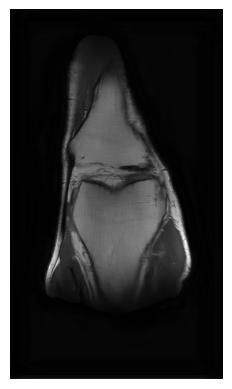

In [12]:
# e2e recon net warm start
e2e_path = '/home/ee2178/scratch/ee2178/ImMAP/trained_nets/knee/LPDS_MRI_Recon_R6/config.json'
e2e_net = load_model(e2e_path, device=device)
e2e_recon, _ = e2e_net(meas_kspace, E=E, sigma=sigma_y)
plot_image(e2e_recon)

In [13]:
# e2e_recon, _ = e2e_net(meas_kspace, E=E, sigma=sigma_y)
# plot_image(e2e_recon)

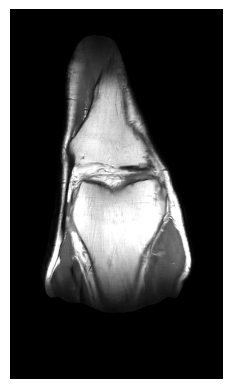

1.000125765800476


In [23]:
# Try just one run of difflpdsnet
sigma_t = torch.tensor([1.0], device = device)
ws = e2e_recon+sigma_t*torch.randn_like(E.H(meas_kspace))
with torch.no_grad():
    v, _ = net(
        meas_kspace, 
        E = E, 
        E_z = D,
        sigma = sigma_y,
        x_init=ws,
        sigma_t=sigma_t,
    )
    organ_mask = torch.ones_like(ws[0,0]) == 1
    nle = torch.sqrt(torch.sum(((ws-v)*organ_mask).abs()**2)/torch.sum(organ_mask))
plot_image(v*Zinv, contrast=True, thresh=1.0)
print(nle.item())

In [15]:
recon = immap2p5(meas_kspace, sigma_y, net, E,    # Require usual inputs (measurent, nle, net, measurement op)
             sigma_max = 1.0,             
             sigma_min=0.05,
             D = D,            # Optional SSDU Operator for Image Domain masking
             organ_mask = None,         # Optional Organ Mask
             ws = gnd_truth, 
             # Base Diffusion Hyperparameters
             beta = 0.05,    # Noise injection ratio, should belong in [0, 1]
             h_0 = 0.01,      # Initial step size
             save_dir = None,           
             verbose = True, 
             )

Iteration 1 complete. Noise level: 0.9991934895515442.
Iteration 2 complete. Noise level: 0.9985460638999939.
Iteration 3 complete. Noise level: 0.9979022741317749.
Iteration 4 complete. Noise level: 0.996688961982727.
Iteration 5 complete. Noise level: 0.9946030974388123.
Iteration 6 complete. Noise level: 0.9921817183494568.
Iteration 7 complete. Noise level: 0.9889873266220093.
Iteration 8 complete. Noise level: 0.985443115234375.
Iteration 9 complete. Noise level: 0.9814322590827942.
Iteration 10 complete. Noise level: 0.9782801270484924.
Iteration 11 complete. Noise level: 0.973892331123352.
Iteration 12 complete. Noise level: 0.969249427318573.
Iteration 13 complete. Noise level: 0.9628958702087402.
Iteration 14 complete. Noise level: 0.9568566679954529.
Iteration 15 complete. Noise level: 0.9505561590194702.
Iteration 16 complete. Noise level: 0.9438420534133911.
Iteration 17 complete. Noise level: 0.9366509914398193.
Iteration 18 complete. Noise level: 0.9303251504898071.
Itera

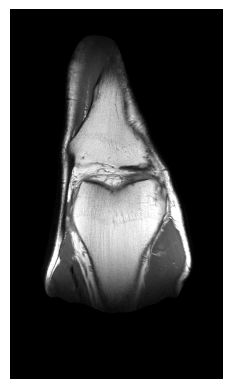

In [16]:
plot_image(
    gnd_truth,
    contrast=True,
    thresh=1.0
)

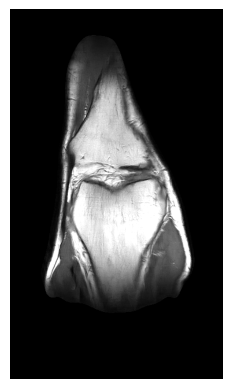

In [26]:
plot_image(
    recon*Zinv,
    contrast=True,
    thresh=1.0
)